Ciscenje teksta...
Dimenzija podataka (Samo Tekst): (2000, 15000)

--- REZULTATI: SAMO TEKST (PUN SKUP ATRIBUTA) ---
    Algoritam  Silhouette  Davies-Bouldin  Calinski-Harabasz       ARI
       KMeans    0.006505       12.625264           8.044571  0.009372
    MiniBatch    0.004193        7.492494           7.208348 -0.000191
Agglomerative    0.003145        8.437468           6.758608 -0.000377
     Spectral    0.004804        8.058433           7.450823 -0.000133
       DBSCAN    0.000000        0.000000           0.000000  0.000000


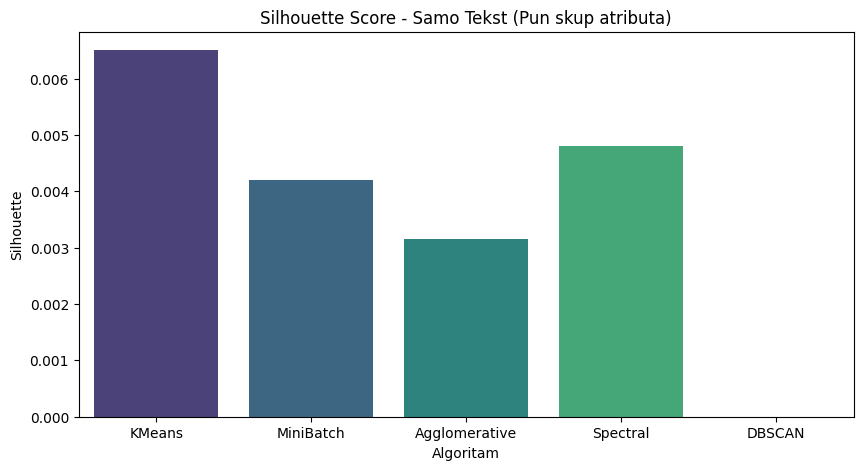

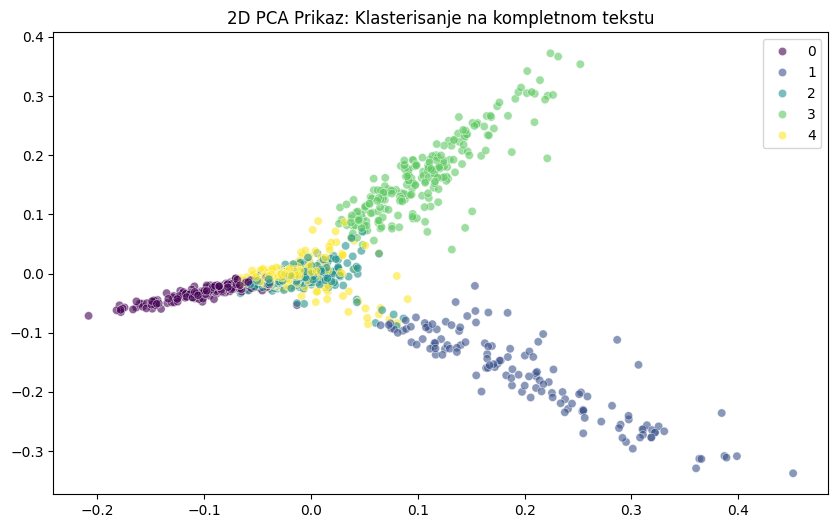

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD  
from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import Normalizer

def clean_text(text):
    text = str(text).lower() # Lowercase
    text = re.sub(r'<.*?>', '', text) # Uklanjanje HTML tagova
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Uklanjanje URL-ova
    text = text.translate(str.maketrans('', '', string.punctuation)) # Uklanjanje interpunkcije
    text = re.sub(r'\s+', ' ', text).strip() # Uklanjanje suvisnih razmaka
    return text

# Ucitavanje i priprema uzorka 
df = pd.read_csv("Reviews_sample_balanced.csv").dropna(subset=['Text']).sample(2000, random_state=42)
df = df.reset_index(drop=True)

print("Ciscenje teksta...")
df['Cleaned_Text'] = df['Text'].apply(clean_text)

# Vektorizacija teksta
tfidf = TfidfVectorizer(max_features=15000, stop_words='english', ngram_range=(1,2))
X_raw = tfidf.fit_transform(df['Cleaned_Text']).toarray()

scaler = Normalizer()
X = scaler.fit_transform(X_raw)

print(f"Dimenzija podataka (Samo Tekst): {X.shape}")

def get_metrics(X, labels, true_labels, name):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    if n_clusters < 2:
        return [name, 0, 0, 0, 0]
    
    mask = labels != -1
    if not any(mask): return [name, 0, 0, 0, 0]

    s_score = silhouette_score(X[mask], labels[mask])
    db_index = davies_bouldin_score(X[mask], labels[mask])
    ch_index = calinski_harabasz_score(X[mask], labels[mask])
    ari = adjusted_rand_score(true_labels[mask], labels[mask])
    
    return [name, s_score, db_index, ch_index, ari]

true_sent = df['Sentiment']
all_results = []

# KMeans
km = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_km = km.fit_predict(X)
all_results.append(get_metrics(X, labels_km, true_sent, "KMeans"))

# MiniBatchKMeans
mb = MiniBatchKMeans(n_clusters=5, random_state=42, batch_size=100)
labels_mb = mb.fit_predict(X)
all_results.append(get_metrics(X, mb.fit_predict(X), true_sent, "MiniBatch"))


# Agglomerative
agg = AgglomerativeClustering(n_clusters=5)
labels_agg = agg.fit_predict(X)
all_results.append(get_metrics(X, agg.fit_predict(X), true_sent, "Agglomerative"))


# Spectral
spec = SpectralClustering(n_clusters=5, affinity='nearest_neighbors', random_state=42)
labels_spec = spec.fit_predict(X)
all_results.append(get_metrics(X, spec.fit_predict(X), true_sent, "Spectral"))


# DBSCAN (sa proverom)
db = DBSCAN(eps=0.5, min_samples=5)
labels_db = db.fit_predict(X)
all_results.append(get_metrics(X, db.fit_predict(X), true_sent, "DBSCAN"))


df_res = pd.DataFrame(all_results, columns=['Algoritam', 'Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz', 'ARI'])

print("\n--- REZULTATI: SAMO TEKST (PUN SKUP ATRIBUTA) ---")
print(df_res.to_string(index=False))

# Grafik
pca_2d = PCA(n_components=2)
coords = pca_2d.fit_transform(X)

plt.figure(figsize=(10,5))
sns.barplot(x='Algoritam', y='Silhouette', data=df_res, hue='Algoritam', palette='viridis', legend=False)
plt.title('Silhouette Score - Samo Tekst (Pun skup atributa)')
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(x=coords[:,0], y=coords[:,1], hue=labels_km, palette='viridis', alpha=0.6)
plt.title('2D PCA Prikaz: Klasterisanje na kompletnom tekstu')
plt.show()


In [6]:
df_res.to_csv("rezultati_text.csv", index=False)